In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle

plt.style.use(['science','notebook'])
import matplotlib
matplotlib.rcParams.update({'font.size': 16})

In [2]:
n_coords = 30
ks = [1,5,10, 15, 20, 25, 30]
n_bests = [1,5,10,20] 

variables = {}
imbalances = {}
for k in ks:
    for n_best in n_bests:
        variables[k, n_best], imbalances[k, n_best] = pickle.load(open(f"./pickles/nbest{n_best}_ncoords{n_coords}_k{k}.p","rb"))

### Imbalances vs selected features for different ks

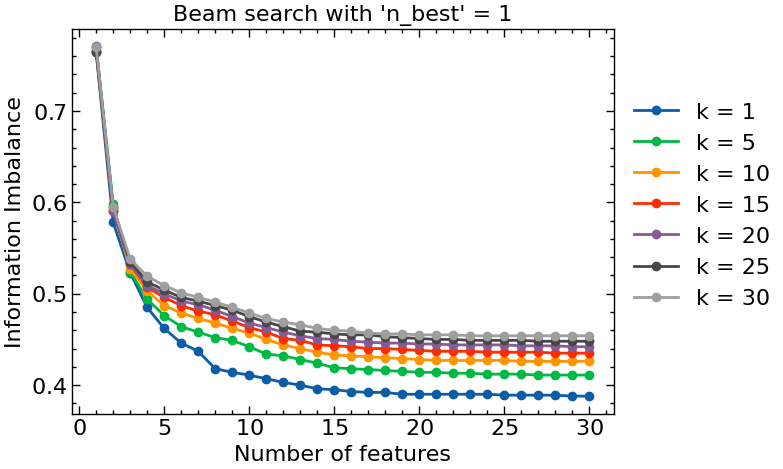

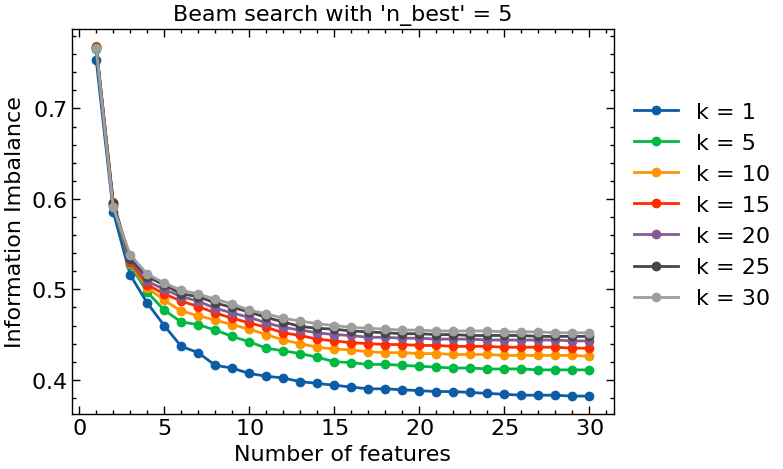

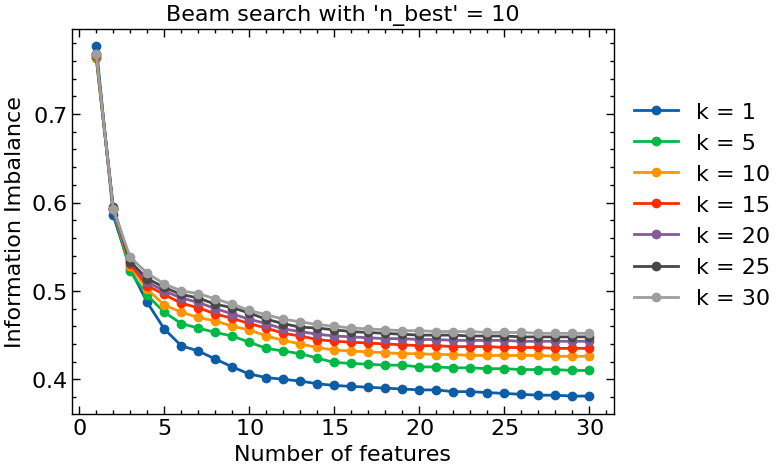

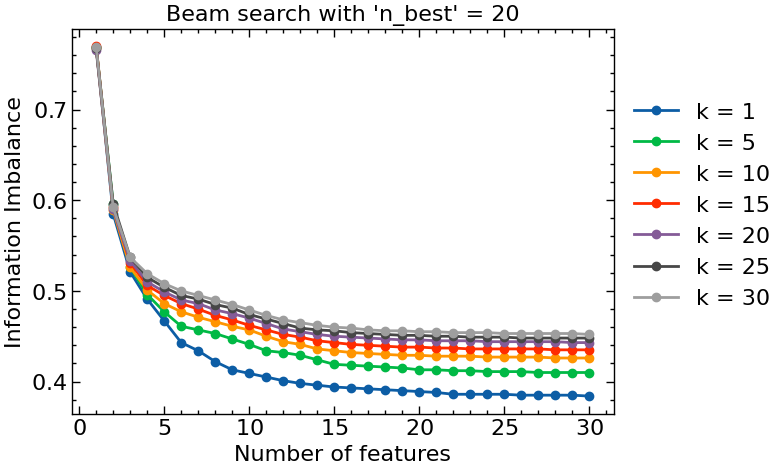

In [45]:
intersections = np.zeros((len(n_bests),len(ks)-1))

for i_plot, n_best in enumerate(n_bests):
    plt.figure(figsize=(7,5))
    for i_k, k in enumerate(ks):
        plt.plot(np.arange(1,n_coords+1), imbalances[k, n_best][:,1], '-o', label=f"k = {k}")
        #print(f"k = {k}:\n\t {variables[k, n_best][-1]}")
        if k > 1:
            intersection_last_first = set(variables[ks[i_k], n_best][-1]).intersection(variables[ks[i_k-1], n_best][-1])
            #print(f"Intersection: {len(intersection_last_first) / n_coords * 100} %\n")
            intersections[i_plot,i_k-1] = len(intersection_last_first) 
    plt.legend(loc=(1.02,0.25))
    plt.xlabel("Number of features")
    plt.ylabel("Information Imbalance")
    plt.title(f"Beam search with 'n_best' = {n_best}")
    plt.savefig(f"./figures/imb_vs_nfeats_legendk_nbest{n_best}.pdf", dpi=300)
    plt.show()

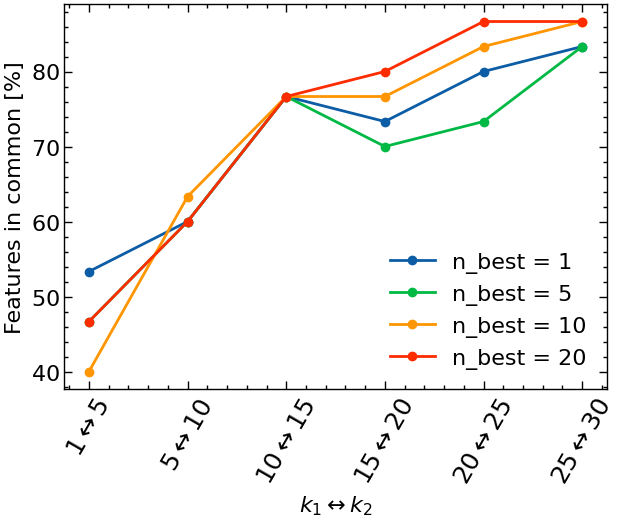

In [46]:
x_ticks_labels = ["$1\\leftrightarrow 5$","$5\\leftrightarrow 10$","$10\\leftrightarrow 15$",
                  "$15\\leftrightarrow 20$","$20\\leftrightarrow 25$","$25\\leftrightarrow 30$"]

fig, ax = plt.subplots(1,figsize=(7,5))
for i, n_best in enumerate(n_bests):
    ax.plot(intersections[i] / n_coords * 100, 'o-', label=f"n_best = {n_best}")
ax.legend()
ax.set_xlabel("$k_1\\leftrightarrow k_2$")
ax.set_ylabel("Features in common [%]")
ax.set_xticks(np.arange(len(ks)-1))
ax.set_xticklabels(x_ticks_labels, rotation=60, fontsize=18)
plt.savefig("./figures/features_in_commmon_legendnbest.pdf", dpi=300)
plt.show()


### Imbalances vs selected features for different n_best

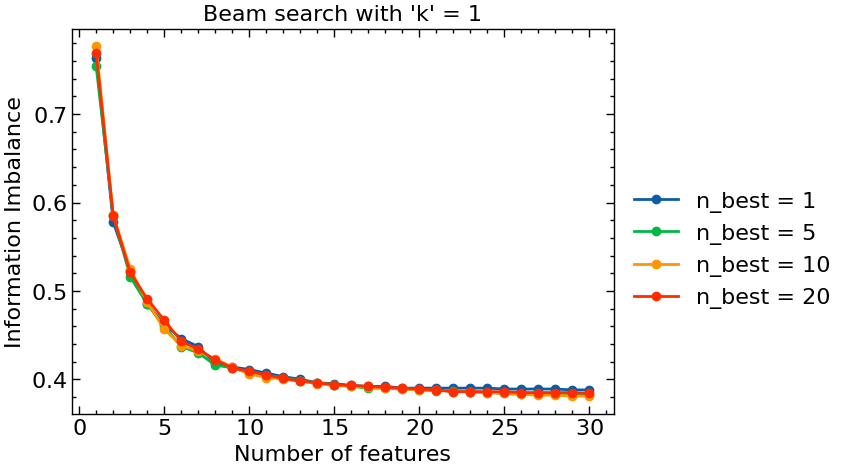

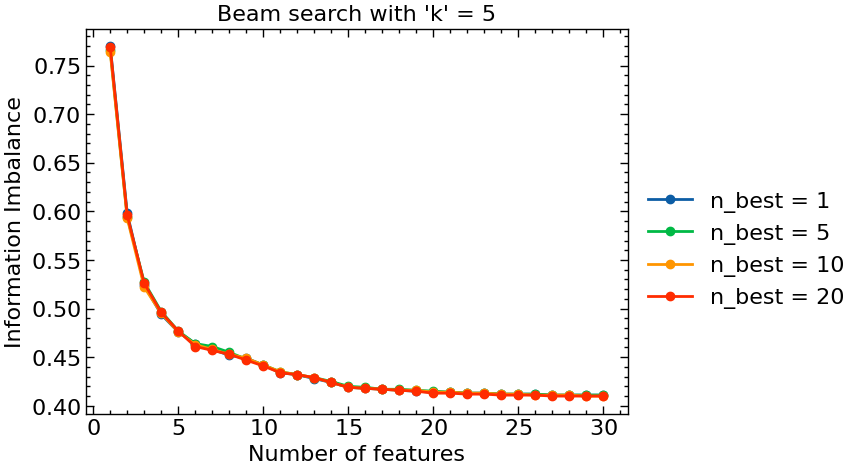

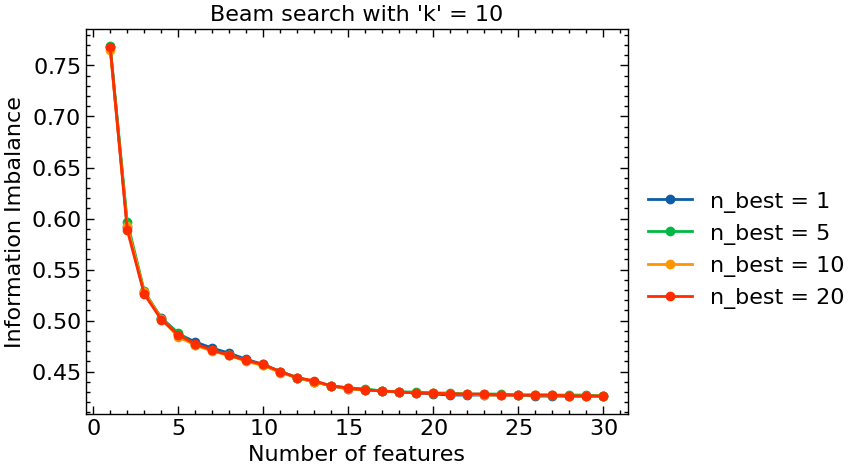

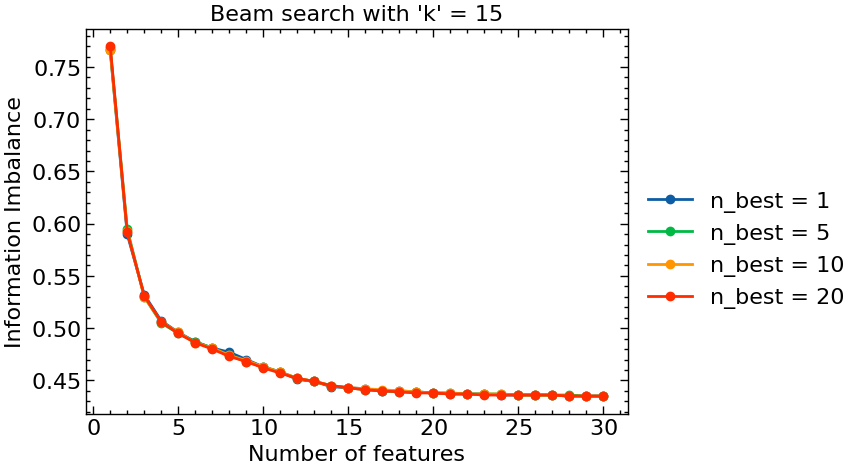

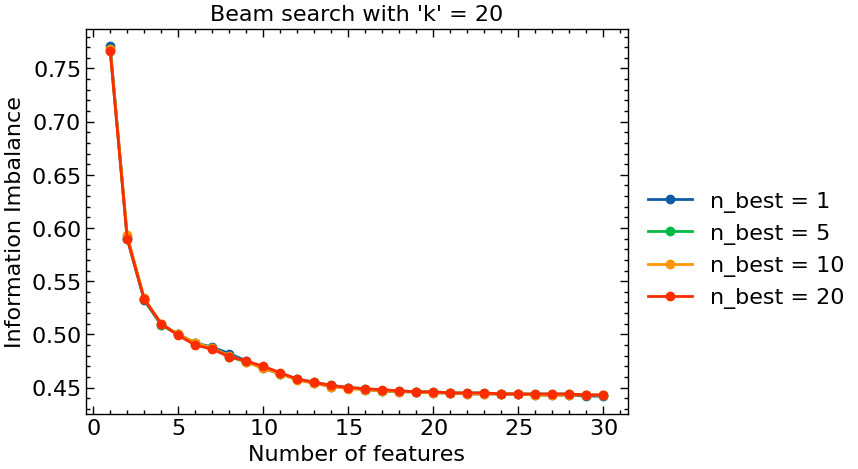

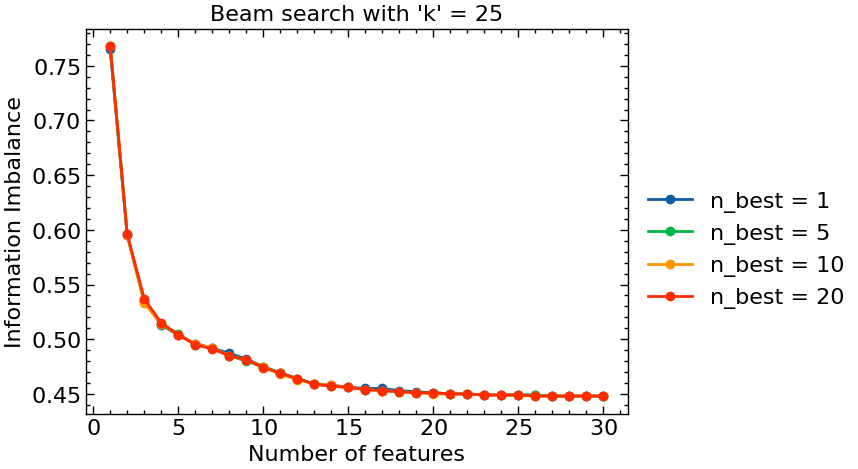

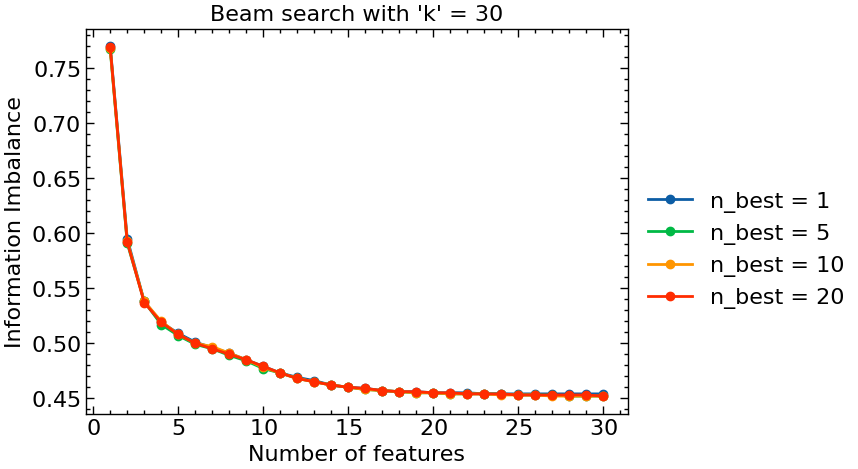

In [41]:
intersections = np.zeros((len(ks),len(n_bests)-1))

for i_k, k in enumerate(ks):
    plt.figure(figsize=(7,5))
    for i_n, n_best in enumerate(n_bests):
        plt.plot(np.arange(1,n_coords+1), imbalances[k, n_best][:,1], '-o', label=f"n_best = {n_best}")
        #print(f"n_best = {n_best}:\n\t {variables[k, n_best][-1]}")
        if n_best > 1:
            intersection_last_first = set(variables[ks[i_k], n_best][-1]).intersection(variables[ks[i_k-1], n_best][-1])
            #print(f"Intersection: {len(intersection_last_first) / n_coords * 100} %\n")
            intersections[i_k,i_n-1] = len(intersection_last_first)
    plt.legend(loc=(1.02,0.25))
    plt.xlabel("Number of features")
    plt.ylabel("Information Imbalance")
    plt.title(f"Beam search with 'k' = {k}")
    plt.savefig(f"./figures/imb_vs_nfeats_legendnbest_k{k}.pdf")
    plt.show()

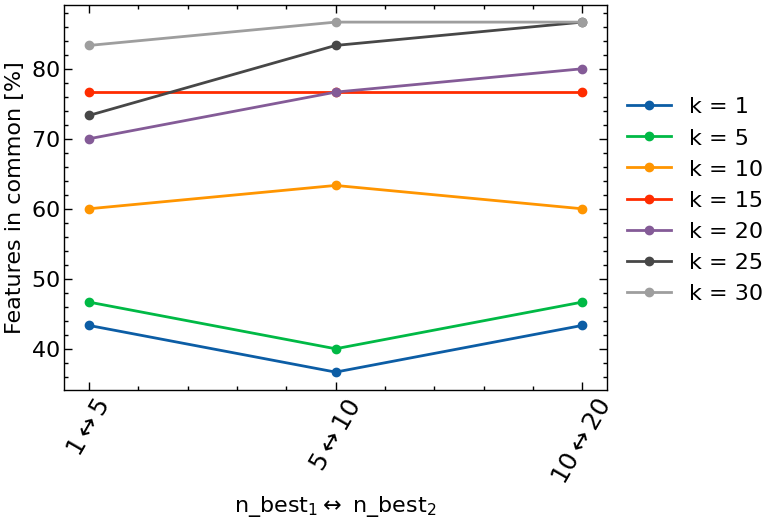

In [44]:
x_ticks_labels = ["$1\\leftrightarrow 5$","$5\\leftrightarrow 10$","$10\\leftrightarrow 20$"]

fig, ax = plt.subplots(1,figsize=(7,5))
for i, k in enumerate(ks):
    ax.plot(intersections[i] / n_coords * 100, 'o-', label=f"k = {k}")
ax.legend(loc=(1.02,0.2))
ax.set_xlabel("n_best$_1 \\leftrightarrow$ n_best$_2$")
ax.set_ylabel("Features in common [%]")
ax.set_xticks([0,1,2])
ax.set_xticklabels(x_ticks_labels, rotation=60, fontsize=18)
#ax.set_xticklabels([1,3,4,5], rotation=60, fontsize=18)
plt.savefig("./figures/features_in_commmon_legendk.pdf", dpi=300)
plt.show()


## Transferability results

In [2]:
n_coords = 30
k = 10 # 30 / 3, to keep same ratio k/N
n_best = 20

variables_train = {}
imbalances_train = {}
imbalances_val1 = {}
imbalances_val2 = {}
for i_fold in range(3):
        variables_train[i_fold], imbalances_train[i_fold], imbalances_val1[i_fold], imbalances_val2[i_fold] = (
            pickle.load(open(f"./pickles_transferability/nbest{n_best}_ncoords{n_coords}_k{k}_fold{i_fold}.p","rb")) 
        )

### Imbalance vs n_features for train and validation sets

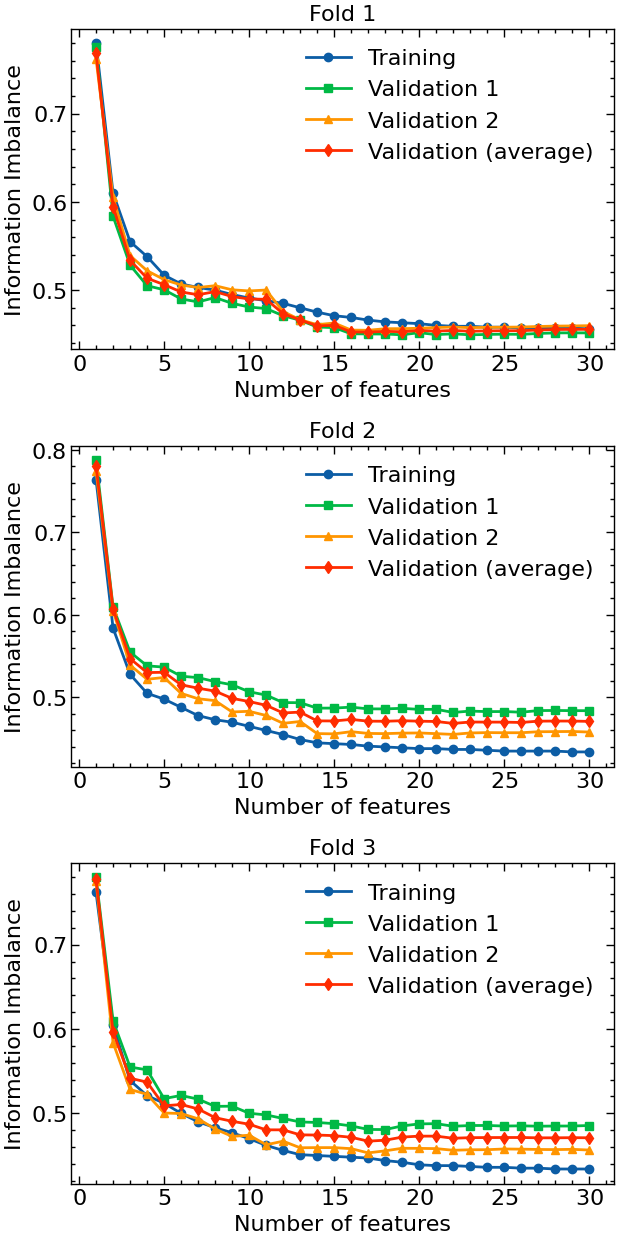

In [10]:
fig, ax = plt.subplots(3,1,figsize=(7,15),gridspec_kw={"hspace": 0.3})

for i_fold in range(3):
    ax[i_fold].plot(np.arange(1,n_coords+1), imbalances_train[i_fold][:,1], 'o-', label="Training")
    ax[i_fold].plot(np.arange(1,n_coords+1), imbalances_val1[i_fold][1,:], 's-', label="Validation 1")
    ax[i_fold].plot(np.arange(1,n_coords+1), imbalances_val2[i_fold][1,:], '^-', label="Validation 2")
    ax[i_fold].plot(np.arange(1,n_coords+1), 0.5*(imbalances_val1[i_fold][1,:]+imbalances_val2[i_fold][1,:]), 'd-', label="Validation (average)")
    ax[i_fold].set(xlabel="Number of features", ylabel="Information Imbalance", title=f"Fold {i_fold+1}")
    ax[i_fold].legend()
plt.savefig("./figures/transferability_imbalances.pdf", dpi=300)
plt.show()


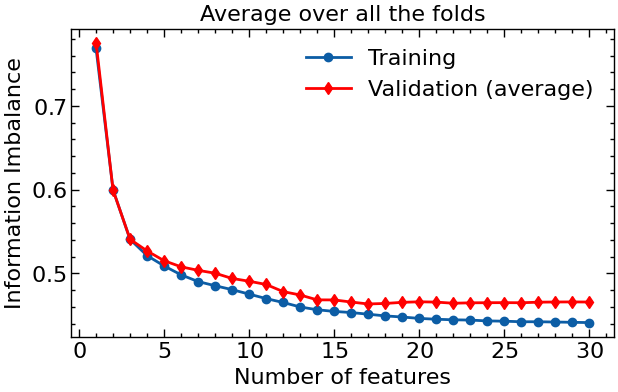

In [14]:
fig, ax = plt.subplots(1,1,figsize=(7,4),gridspec_kw={"hspace": 0.3})

ax.plot(np.arange(1,n_coords+1), (imbalances_train[0][:,1]+imbalances_train[1][:,1]+imbalances_train[2][:,1])/3, 'o-', label="Training")
ax.plot(np.arange(1,n_coords+1), 0.5*(imbalances_val1[0][1,:]+imbalances_val2[0][1,:]
                                      + imbalances_val1[1][1,:]+imbalances_val2[1][1,:]
                                      + imbalances_val1[2][1,:]+imbalances_val2[2][1,:]) / 3, 'd-', color="red", label="Validation (average)")
ax.set(xlabel="Number of features", ylabel="Information Imbalance", title=f"Average over all the folds")
ax.legend()
plt.savefig("./figures/transferability_imbalances_average.pdf", dpi=300)
plt.show()


### % common features in three independent trainings

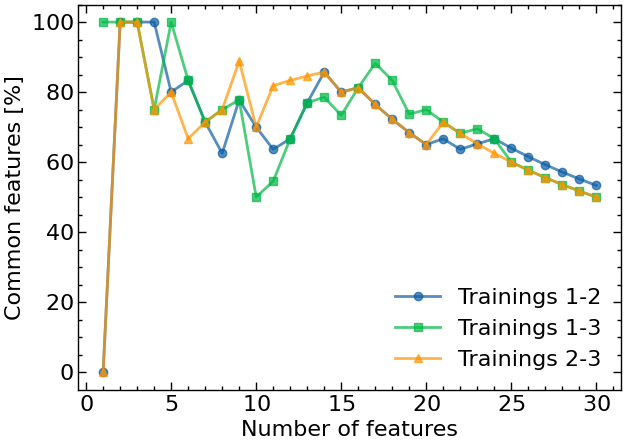

In [8]:
fig, ax = plt.subplots(1,figsize=(7,5))

intersections_12 = np.zeros(n_coords)
intersections_13 = np.zeros(n_coords)
intersections_23 = np.zeros(n_coords)
for i_feat in range(n_coords):
    intersection_train1_train2 = set(variables_train[0][i_feat]).intersection(variables_train[1][i_feat])
    intersection_train1_train3 = set(variables_train[0][i_feat]).intersection(variables_train[2][i_feat])
    intersection_train2_train3 = set(variables_train[1][i_feat]).intersection(variables_train[2][i_feat])
    intersections_12[i_feat] = len(intersection_train1_train2)
    intersections_13[i_feat] = len(intersection_train1_train3)
    intersections_23[i_feat] = len(intersection_train2_train3)
ax.plot(np.arange(1,n_coords+1), intersections_12 / np.arange(1,n_coords+1) * 100, 'o-', label=f"Trainings 1-2", alpha=0.7)
ax.plot(np.arange(1,n_coords+1), intersections_13 / np.arange(1,n_coords+1) * 100, 's-', label=f"Trainings 1-3", alpha=0.7)
ax.plot(np.arange(1,n_coords+1), intersections_23 / np.arange(1,n_coords+1) * 100, '^-', label=f"Trainings 2-3", alpha=0.7)
ax.set(xlabel="Number of features", ylabel="Common features [%]")
ax.legend()
plt.savefig("./figures/transferability_features.pdf", dpi=300)
plt.show()